# 第19章: 回帰分析その他

## 学習目標
- リッジ回帰を理解し適用できる
- LASSOを理解し適用できる
- 多項式回帰を実行できる
- スプライン回帰を理解する

## 📋 学習メタ情報

### 推定学習時間
**110〜140分**

### 難易度
**★★★★☆** (5段階中4)

---

## 🎯 なぜこの章を学ぶのか？

この章の内容は、実務での統計的データ分析に直結する重要なトピックです。理論と実践の両面から理解を深めましょう。

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import minimize
import seaborn as sns

plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style('whitegrid')
np.random.seed(42)

## 19.1 リッジ回帰

### 問題設定
多重共線性がある場合、OLS推定量は不安定になる。

### リッジ回帰の目的関数
$$\min_{\boldsymbol{\beta}} \left\{ \sum_{i=1}^{n}(y_i - \mathbf{x}_i^T\boldsymbol{\beta})^2 + \lambda \sum_{j=1}^{p} \beta_j^2 \right\}$$

### リッジ推定量
$$\hat{\boldsymbol{\beta}}_{ridge} = (\mathbf{X}^T\mathbf{X} + \lambda \mathbf{I})^{-1}\mathbf{X}^T\mathbf{y}$$

### 特徴
- L2正則化（係数の二乗和にペナルティ）
- 係数を0に縮小するが、完全に0にはならない
- バイアス-バリアンスのトレードオフを調整

In [2]:
# リッジ回帰の実装
def ridge_regression(X, y, lam):
    """Perform ridge regression."""
    n, p = X.shape
    I = np.eye(p)
    I[0, 0] = 0  # Don't penalize intercept
    
    beta = np.linalg.inv(X.T @ X + lam * I) @ X.T @ y
    return beta

# Generate data with multicollinearity
np.random.seed(123)

n = 100
p = 5

# Create correlated predictors
X_base = np.random.randn(n, 2)
X_corr = np.column_stack([
    X_base[:, 0],
    X_base[:, 0] + np.random.randn(n) * 0.1,  # High correlation with X1
    X_base[:, 1],
    X_base[:, 1] + np.random.randn(n) * 0.1,  # High correlation with X3
    np.random.randn(n)
])

# True coefficients
beta_true = np.array([2, 1, 0, 1, 0, 0.5])  # Including intercept

# Generate response
X_design = np.column_stack([np.ones(n), X_corr])
y = X_design @ beta_true + np.random.randn(n) * 0.5

# OLS
beta_ols = np.linalg.lstsq(X_design, y, rcond=None)[0]

print("リッジ回帰 vs OLS")
print("="*60)

# Compare for different lambda values
lambdas = [0, 0.1, 1, 10, 100]

print(f"\n{'λ':>8} | " + " ".join([f"β{i}" for i in range(6)]))
print("-"*60)
print(f"{'True':>8} | " + " ".join([f"{b:>6.3f}" for b in beta_true]))

for lam in lambdas:
    beta_ridge = ridge_regression(X_design, y, lam)
    print(f"{lam:>8.1f} | " + " ".join([f"{b:>6.3f}" for b in beta_ridge]))

リッジ回帰 vs OLS

       λ | β0 β1 β2 β3 β4 β5
------------------------------------------------------------
    True |  2.000  1.000  0.000  1.000  0.000  0.500
     0.0 |  2.055  0.785  0.149  1.296 -0.333  0.502
     0.1 |  2.057  0.752  0.181  1.123 -0.163  0.499
     1.0 |  2.064  0.595  0.335  0.700  0.251  0.489
    10.0 |  2.069  0.462  0.430  0.486  0.433  0.451
   100.0 |  2.079  0.317  0.318  0.349  0.349  0.265


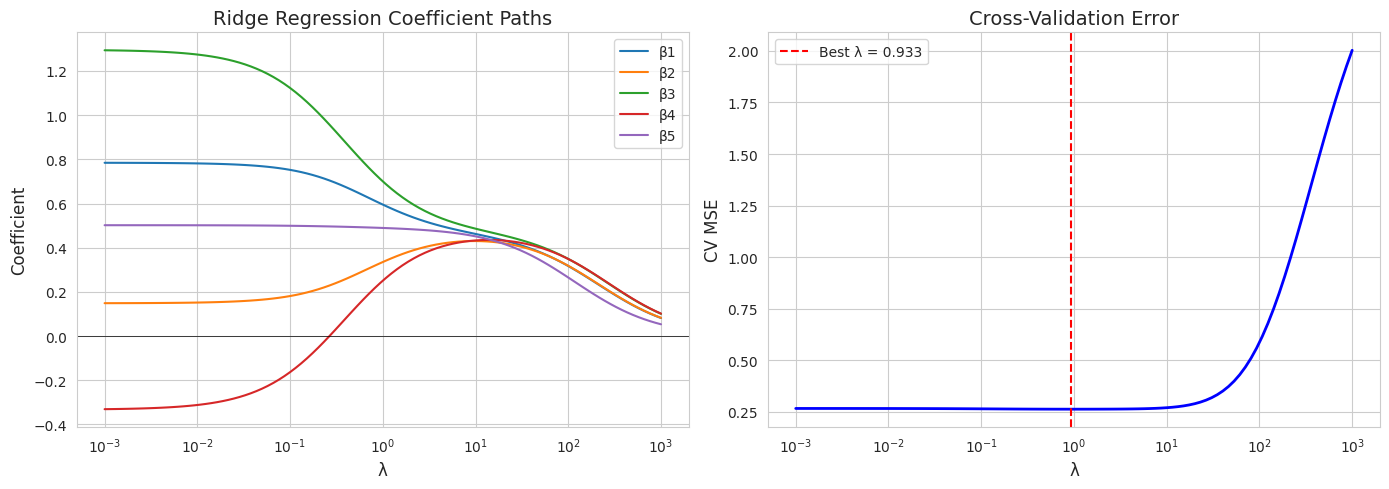


最適な λ = 0.9326
最適モデルの係数: [2.06380466 0.60115484 0.32957527 0.71197509 0.23947147 0.48988871]


In [3]:
# リッジ係数のパス
lambdas = np.logspace(-3, 3, 100)
coefficients = np.zeros((len(lambdas), 6))

for i, lam in enumerate(lambdas):
    coefficients[i] = ridge_regression(X_design, y, lam)

# Plot coefficient paths
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for j in range(1, 6):  # Skip intercept
    axes[0].plot(lambdas, coefficients[:, j], label=f'β{j}')

axes[0].set_xscale('log')
axes[0].set_xlabel('λ', fontsize=12)
axes[0].set_ylabel('Coefficient', fontsize=12)
axes[0].set_title('Ridge Regression Coefficient Paths', fontsize=14)
axes[0].legend()
axes[0].axhline(0, color='black', linestyle='-', linewidth=0.5)

# Cross-validation for lambda selection
from sklearn.model_selection import KFold

def ridge_cv(X, y, lambdas, k=5):
    """Cross-validation for ridge regression."""
    kf = KFold(n_splits=k, shuffle=True, random_state=42)
    cv_errors = np.zeros(len(lambdas))
    
    for i, lam in enumerate(lambdas):
        fold_errors = []
        for train_idx, val_idx in kf.split(X):
            X_train, X_val = X[train_idx], X[val_idx]
            y_train, y_val = y[train_idx], y[val_idx]
            
            beta = ridge_regression(X_train, y_train, lam)
            y_pred = X_val @ beta
            mse = np.mean((y_val - y_pred)**2)
            fold_errors.append(mse)
        
        cv_errors[i] = np.mean(fold_errors)
    
    return cv_errors

cv_errors = ridge_cv(X_design, y, lambdas)
best_lambda = lambdas[np.argmin(cv_errors)]

axes[1].plot(lambdas, cv_errors, 'b-', linewidth=2)
axes[1].axvline(best_lambda, color='red', linestyle='--', 
                label=f'Best λ = {best_lambda:.3f}')
axes[1].set_xscale('log')
axes[1].set_xlabel('λ', fontsize=12)
axes[1].set_ylabel('CV MSE', fontsize=12)
axes[1].set_title('Cross-Validation Error', fontsize=14)
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\n最適な λ = {best_lambda:.4f}")
print(f"最適モデルの係数: {ridge_regression(X_design, y, best_lambda)}")

## 19.2 LASSO

### 目的関数
$$\min_{\boldsymbol{\beta}} \left\{ \sum_{i=1}^{n}(y_i - \mathbf{x}_i^T\boldsymbol{\beta})^2 + \lambda \sum_{j=1}^{p} |\beta_j| \right\}$$

### 特徴
- L1正則化（係数の絶対値和にペナルティ）
- 変数選択機能：係数を完全に0にできる
- スパースモデルを生成

### リッジとLASSOの比較
- リッジ: 全ての変数を保持、係数を縮小
- LASSO: 不要な変数を除去（スパース解）

In [4]:
# LASSOの実装（座標降下法）
def soft_threshold(x, lam):
    """Soft thresholding operator."""
    return np.sign(x) * np.maximum(np.abs(x) - lam, 0)

def lasso_coordinate_descent(X, y, lam, max_iter=1000, tol=1e-6):
    """LASSO using coordinate descent."""
    n, p = X.shape
    beta = np.zeros(p)
    
    # Precompute
    X_norm_sq = np.sum(X**2, axis=0)
    
    for iteration in range(max_iter):
        beta_old = beta.copy()
        
        for j in range(p):
            # Residual without j-th predictor
            r_j = y - X @ beta + X[:, j] * beta[j]
            
            # Update beta_j
            if j == 0:  # Don't penalize intercept
                beta[j] = np.sum(X[:, j] * r_j) / X_norm_sq[j]
            else:
                rho_j = np.sum(X[:, j] * r_j)
                beta[j] = soft_threshold(rho_j, lam * n) / X_norm_sq[j]
        
        # Check convergence
        if np.max(np.abs(beta - beta_old)) < tol:
            break
    
    return beta

# Compare Ridge and LASSO
print("リッジ vs LASSO")
print("="*60)

lambdas_test = [0.01, 0.1, 1]

print(f"\n{'Method':>10} {'λ':>8} | " + " ".join([f"β{i}" for i in range(1, 6)]))
print("-"*60)

for lam in lambdas_test:
    beta_ridge = ridge_regression(X_design, y, lam)[1:]
    beta_lasso = lasso_coordinate_descent(X_design, y, lam)[1:]
    
    print(f"{'Ridge':>10} {lam:>8.2f} | " + " ".join([f"{b:>6.3f}" for b in beta_ridge]))
    print(f"{'LASSO':>10} {lam:>8.2f} | " + " ".join([f"{b:>6.3f}" for b in beta_lasso]))
    print("-"*60)

リッジ vs LASSO

    Method        λ | β1 β2 β3 β4 β5
------------------------------------------------------------
     Ridge     0.01 |  0.782  0.152  1.274 -0.312  0.502
     LASSO     0.01 |  0.823  0.104  0.951  0.000  0.490
------------------------------------------------------------
     Ridge     0.10 |  0.752  0.181  1.123 -0.163  0.499
     LASSO     0.10 |  0.597  0.242  0.887  0.000  0.410
------------------------------------------------------------
     Ridge     1.00 |  0.595  0.335  0.700  0.251  0.489
     LASSO     1.00 |  0.000  0.000  0.000  0.225  0.000
------------------------------------------------------------


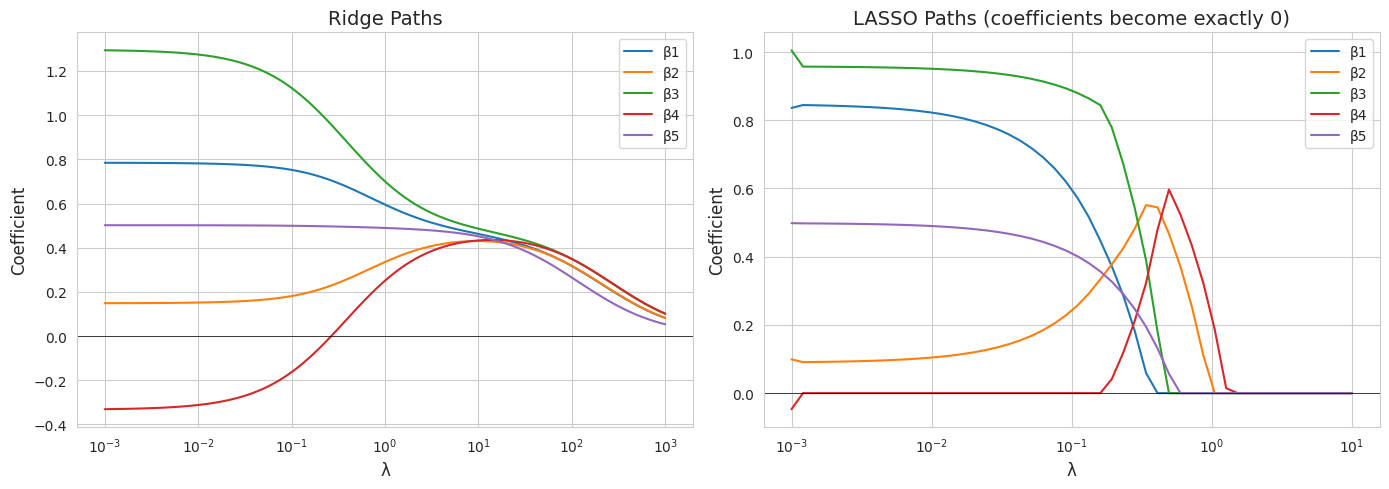

In [5]:
# LASSO係数のパス
lambdas_lasso = np.logspace(-3, 1, 50)
coef_lasso = np.zeros((len(lambdas_lasso), 6))

for i, lam in enumerate(lambdas_lasso):
    coef_lasso[i] = lasso_coordinate_descent(X_design, y, lam)

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Ridge path
for j in range(1, 6):
    axes[0].plot(lambdas, coefficients[:, j], label=f'β{j}')
axes[0].set_xscale('log')
axes[0].set_xlabel('λ', fontsize=12)
axes[0].set_ylabel('Coefficient', fontsize=12)
axes[0].set_title('Ridge Paths', fontsize=14)
axes[0].legend()
axes[0].axhline(0, color='black', linestyle='-', linewidth=0.5)

# LASSO path
for j in range(1, 6):
    axes[1].plot(lambdas_lasso, coef_lasso[:, j], label=f'β{j}')
axes[1].set_xscale('log')
axes[1].set_xlabel('λ', fontsize=12)
axes[1].set_ylabel('Coefficient', fontsize=12)
axes[1].set_title('LASSO Paths (coefficients become exactly 0)', fontsize=14)
axes[1].legend()
axes[1].axhline(0, color='black', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.show()

## 19.3 多項式回帰

### モデル
$$Y = \beta_0 + \beta_1 X + \beta_2 X^2 + \cdots + \beta_d X^d + \varepsilon$$

### 特徴
- Xの非線形関係をモデル化
- 次数が高いと過学習のリスク
- 基底関数を使った線形モデルとして扱える

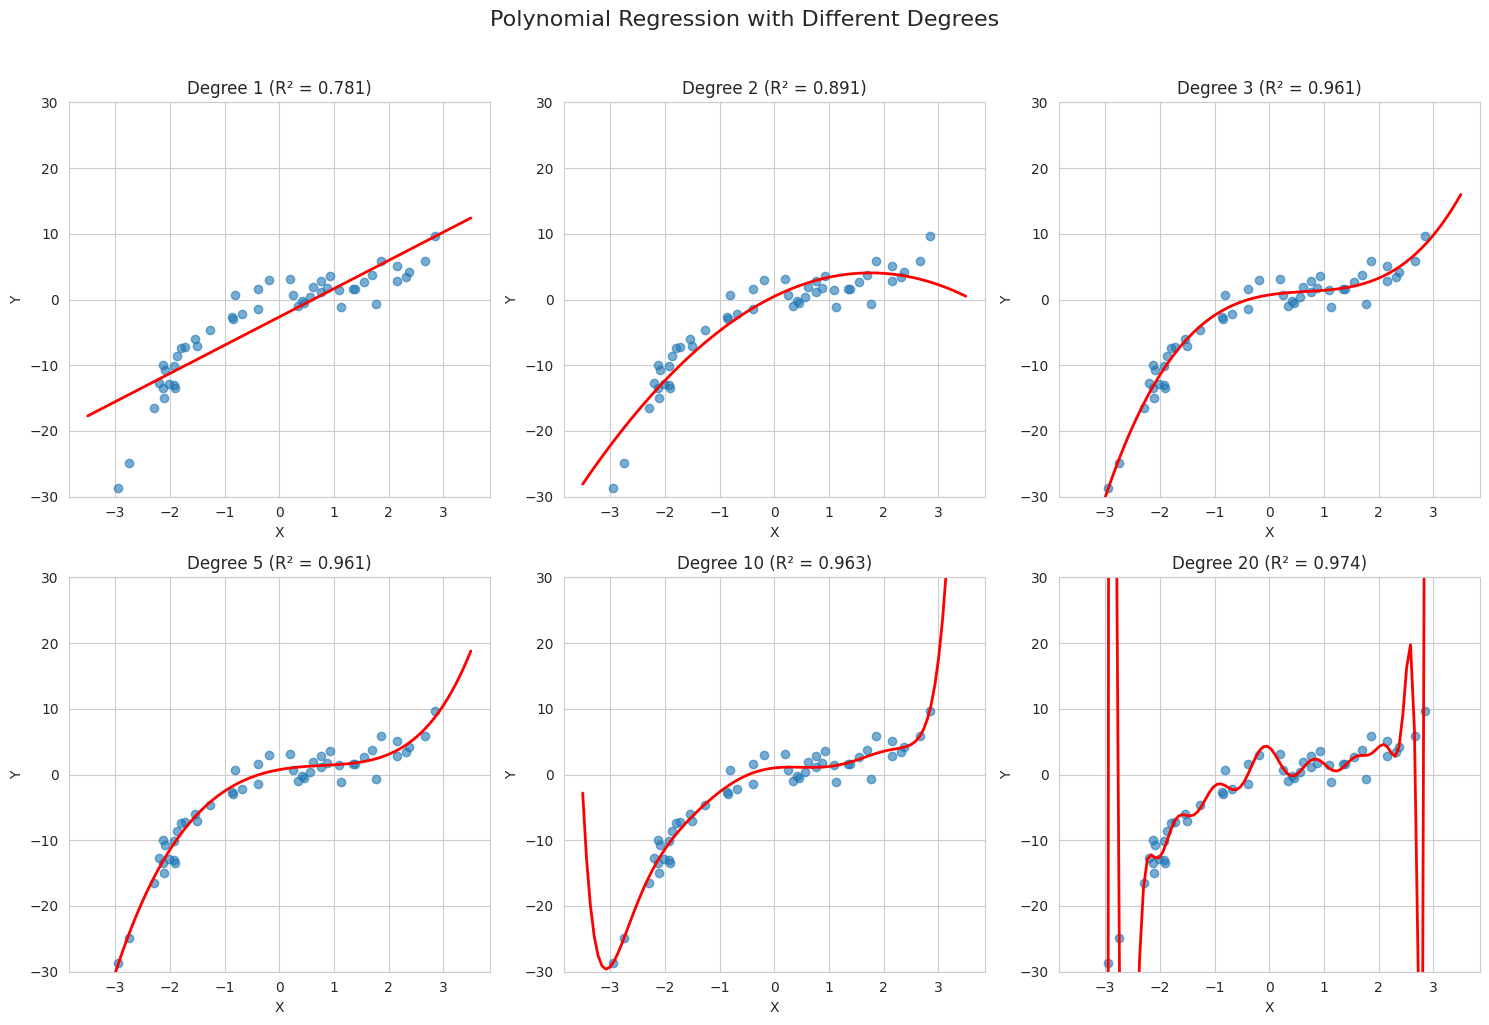

In [6]:
# 多項式回帰
np.random.seed(456)

# Generate nonlinear data
n = 50
X_poly = np.random.uniform(-3, 3, n)
Y_poly = 0.5 * X_poly**3 - X_poly**2 + 2*X_poly + np.random.randn(n) * 2

def polynomial_regression(X, y, degree):
    """Fit polynomial regression of given degree."""
    # Create polynomial features
    X_design = np.column_stack([X**d for d in range(degree + 1)])
    beta = np.linalg.lstsq(X_design, y, rcond=None)[0]
    return beta

# Fit different degrees
degrees = [1, 2, 3, 5, 10, 20]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

X_plot = np.linspace(-3.5, 3.5, 100)

for idx, degree in enumerate(degrees):
    beta = polynomial_regression(X_poly, Y_poly, degree)
    
    # Predict
    X_plot_design = np.column_stack([X_plot**d for d in range(degree + 1)])
    Y_pred = X_plot_design @ beta
    
    # Calculate R-squared
    Y_fit = np.column_stack([X_poly**d for d in range(degree + 1)]) @ beta
    SS_res = np.sum((Y_poly - Y_fit)**2)
    SS_tot = np.sum((Y_poly - np.mean(Y_poly))**2)
    R2 = 1 - SS_res/SS_tot
    
    axes[idx].scatter(X_poly, Y_poly, alpha=0.6)
    axes[idx].plot(X_plot, Y_pred, 'r-', linewidth=2)
    axes[idx].set_xlabel('X', fontsize=10)
    axes[idx].set_ylabel('Y', fontsize=10)
    axes[idx].set_title(f'Degree {degree} (R² = {R2:.3f})', fontsize=12)
    axes[idx].set_ylim(-30, 30)

plt.suptitle('Polynomial Regression with Different Degrees', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

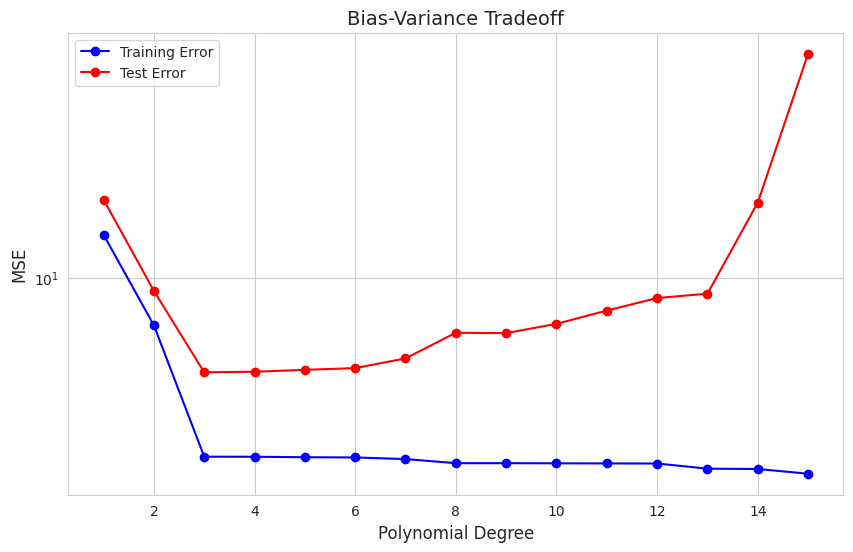

最適な次数: 3
最小テスト誤差: 4.8035


In [7]:
# バイアス-バリアンスのトレードオフ
degrees = range(1, 16)
train_errors = []
test_errors = []

# Generate test data
X_test = np.random.uniform(-3, 3, 100)
Y_test = 0.5 * X_test**3 - X_test**2 + 2*X_test + np.random.randn(100) * 2

for degree in degrees:
    beta = polynomial_regression(X_poly, Y_poly, degree)
    
    # Training error
    X_train_design = np.column_stack([X_poly**d for d in range(degree + 1)])
    Y_train_pred = X_train_design @ beta
    train_mse = np.mean((Y_poly - Y_train_pred)**2)
    train_errors.append(train_mse)
    
    # Test error
    X_test_design = np.column_stack([X_test**d for d in range(degree + 1)])
    Y_test_pred = X_test_design @ beta
    test_mse = np.mean((Y_test - Y_test_pred)**2)
    test_errors.append(test_mse)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(degrees, train_errors, 'b-o', label='Training Error')
plt.plot(degrees, test_errors, 'r-o', label='Test Error')
plt.xlabel('Polynomial Degree', fontsize=12)
plt.ylabel('MSE', fontsize=12)
plt.title('Bias-Variance Tradeoff', fontsize=14)
plt.legend()
plt.yscale('log')
plt.show()

print(f"最適な次数: {degrees[np.argmin(test_errors)]}")
print(f"最小テスト誤差: {min(test_errors):.4f}")

## 19.4 スプライン回帰

### 概念
区分的多項式関数を滑らかに接続

### 3次スプライン
各区間で3次多項式、接続点（ノット）で2階導関数まで連続

### 切断べき基底
$$(x - \xi)_+ = \begin{cases} x - \xi & x > \xi \\ 0 & x \leq \xi \end{cases}$$

### 自然スプライン
境界で線形になるよう制約

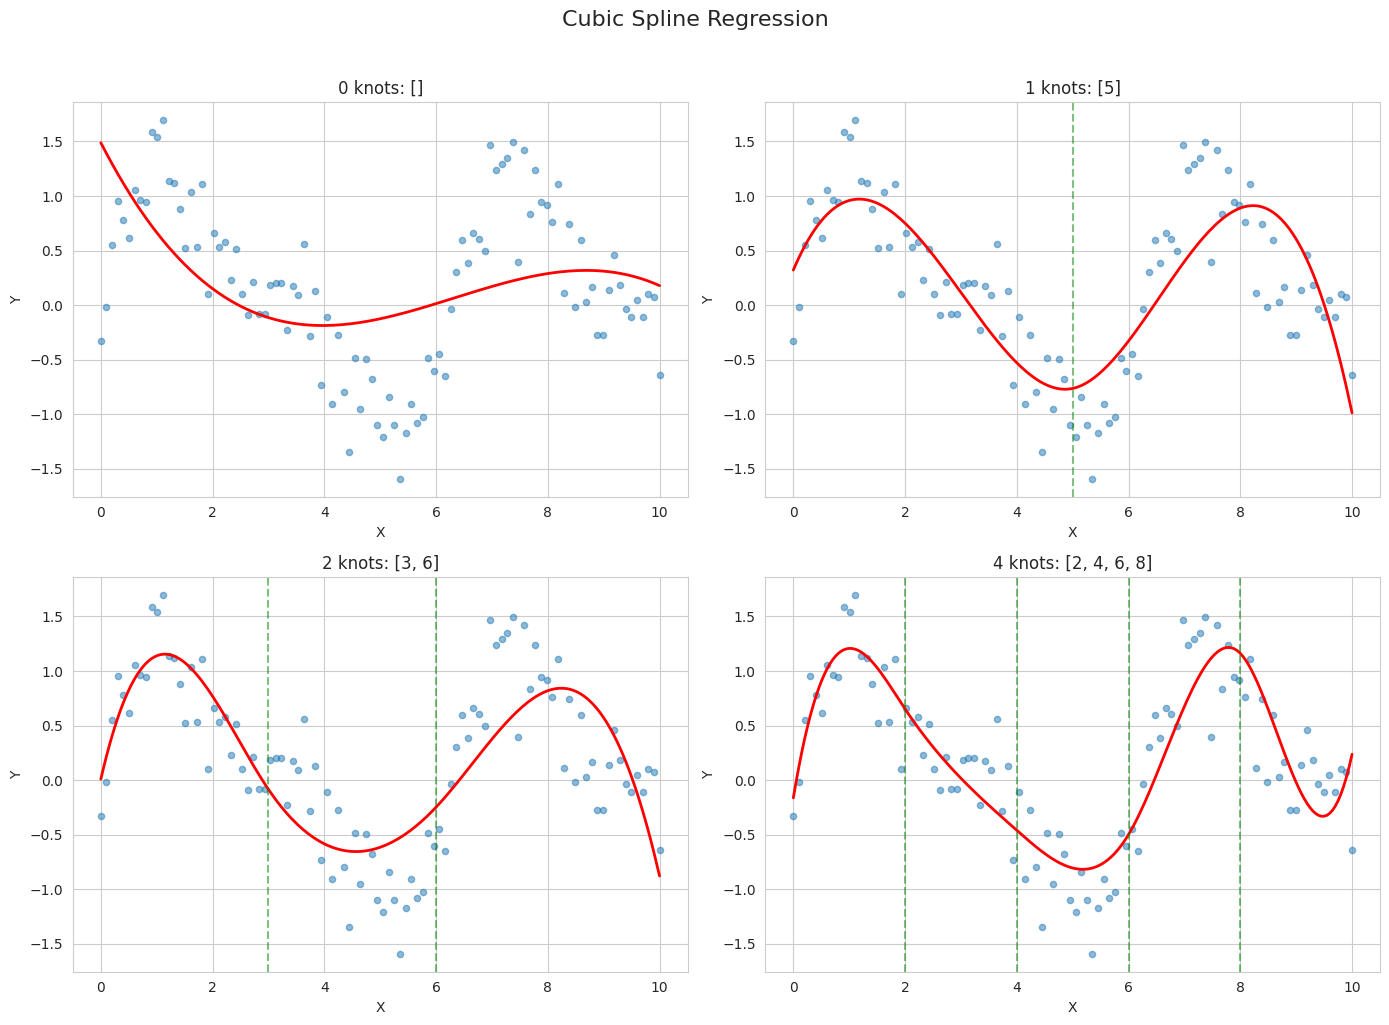

In [8]:
# スプライン回帰の実装
def truncated_power(x, knot, degree):
    """Truncated power basis function."""
    return np.maximum(0, x - knot)**degree

def cubic_spline_basis(X, knots):
    """Create cubic spline basis."""
    n = len(X)
    k = len(knots)
    
    # Base polynomial terms
    basis = np.column_stack([np.ones(n), X, X**2, X**3])
    
    # Add truncated power basis for each knot
    for knot in knots:
        basis = np.column_stack([basis, truncated_power(X, knot, 3)])
    
    return basis

# Generate data
np.random.seed(789)

n = 100
X_spline = np.linspace(0, 10, n)
Y_spline = np.sin(X_spline) + 0.5 * np.sin(2*X_spline) + np.random.randn(n) * 0.3

# Fit with different numbers of knots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

knot_configs = [
    [],
    [5],
    [3, 6],
    [2, 4, 6, 8]
]

X_plot = np.linspace(0, 10, 200)

for idx, knots in enumerate(knot_configs):
    ax = axes.flatten()[idx]
    
    # Create basis and fit
    basis = cubic_spline_basis(X_spline, knots)
    beta = np.linalg.lstsq(basis, Y_spline, rcond=None)[0]
    
    # Predict
    basis_plot = cubic_spline_basis(X_plot, knots)
    Y_pred = basis_plot @ beta
    
    ax.scatter(X_spline, Y_spline, alpha=0.5, s=20)
    ax.plot(X_plot, Y_pred, 'r-', linewidth=2)
    
    # Mark knots
    for knot in knots:
        ax.axvline(knot, color='green', linestyle='--', alpha=0.5)
    
    ax.set_xlabel('X', fontsize=10)
    ax.set_ylabel('Y', fontsize=10)
    ax.set_title(f'{len(knots)} knots: {knots}', fontsize=12)

plt.suptitle('Cubic Spline Regression', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

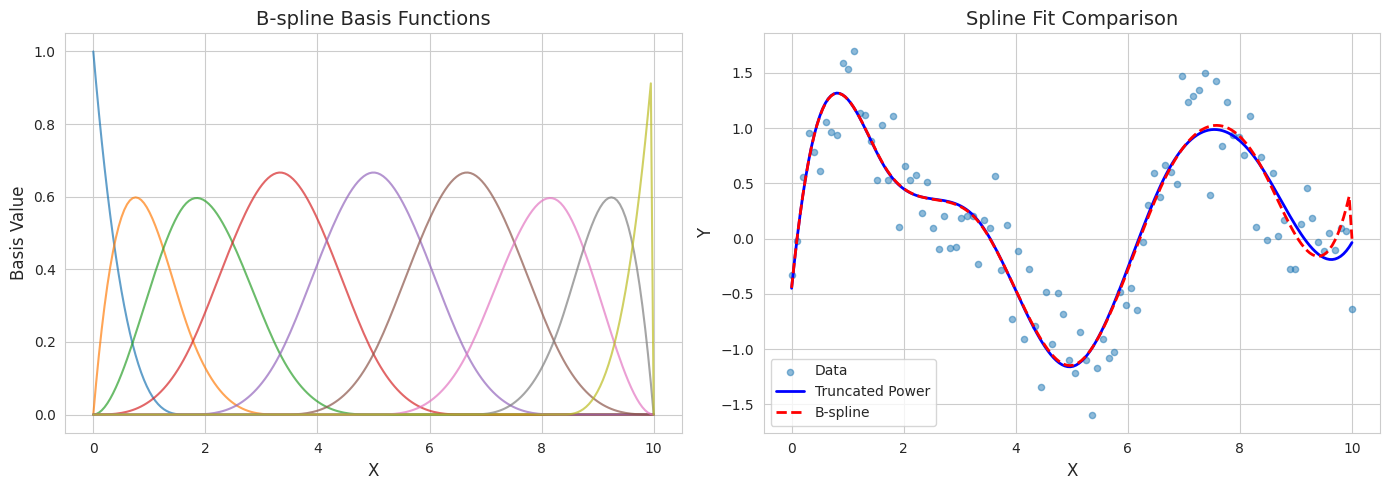

In [9]:
# Bスプラインの実装
def bspline_basis(X, knots, degree=3):
    """Create B-spline basis using recursive definition."""
    # Extend knots
    knots = np.concatenate([[knots[0]]*(degree), knots, [knots[-1]]*(degree)])
    n_basis = len(knots) - degree - 1
    
    def B(i, k, t, knots):
        """Recursive B-spline basis."""
        if k == 0:
            return ((knots[i] <= t) & (t < knots[i+1])).astype(float)
        
        w1 = 0 if knots[i+k] == knots[i] else (t - knots[i]) / (knots[i+k] - knots[i])
        w2 = 0 if knots[i+k+1] == knots[i+1] else (knots[i+k+1] - t) / (knots[i+k+1] - knots[i+1])
        
        return w1 * B(i, k-1, t, knots) + w2 * B(i+1, k-1, t, knots)
    
    basis = np.zeros((len(X), n_basis))
    for i in range(n_basis):
        basis[:, i] = B(i, degree, X, knots)
    
    return basis

# Compare spline types
knots = np.linspace(0, 10, 7)  # 7 knots

# Fit B-spline
basis_b = bspline_basis(X_spline, knots)
beta_b = np.linalg.lstsq(basis_b, Y_spline, rcond=None)[0]

# Fit truncated power spline
basis_tp = cubic_spline_basis(X_spline, knots[1:-1])  # Interior knots only
beta_tp = np.linalg.lstsq(basis_tp, Y_spline, rcond=None)[0]

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# B-spline basis functions
basis_b_plot = bspline_basis(X_plot, knots)
for i in range(basis_b_plot.shape[1]):
    axes[0].plot(X_plot, basis_b_plot[:, i], alpha=0.7)
axes[0].set_xlabel('X', fontsize=12)
axes[0].set_ylabel('Basis Value', fontsize=12)
axes[0].set_title('B-spline Basis Functions', fontsize=14)

# Fitted curves
Y_pred_b = basis_b_plot @ beta_b
basis_tp_plot = cubic_spline_basis(X_plot, knots[1:-1])
Y_pred_tp = basis_tp_plot @ beta_tp

axes[1].scatter(X_spline, Y_spline, alpha=0.5, s=20, label='Data')
axes[1].plot(X_plot, Y_pred_tp, 'b-', linewidth=2, label='Truncated Power')
axes[1].plot(X_plot, Y_pred_b, 'r--', linewidth=2, label='B-spline')
axes[1].set_xlabel('X', fontsize=12)
axes[1].set_ylabel('Y', fontsize=12)
axes[1].set_title('Spline Fit Comparison', fontsize=14)
axes[1].legend()

plt.tight_layout()
plt.show()

## 19.5 練習問題

### 問題1
リッジ回帰とLASSOの違いを説明し、それぞれの適用場面を述べよ。

### 問題2
以下のデータに対して3次多項式回帰を行い、係数を求めよ。

X = [1, 2, 3, 4, 5]
Y = [1, 8, 27, 60, 125]

### 問題3
多項式回帰の次数を選択する方法について説明せよ。

In [10]:
# 問題1の解答
print("問題1: リッジ回帰とLASSOの比較")
print("="*60)

print("""
【リッジ回帰】
- ペナルティ: L2（係数の二乗和）
- 特徴: 係数を0に近づけるが、完全に0にはならない
- 適用場面:
  * 多重共線性がある場合
  * 全ての変数が予測に関連すると考えられる場合
  * 安定した係数推定が必要な場合

【LASSO】
- ペナルティ: L1（係数の絶対値和）
- 特徴: 係数を完全に0にできる（変数選択）
- 適用場面:
  * 変数選択が必要な場合
  * スパースモデルが適切と考えられる場合
  * 解釈可能性を重視する場合
""")

問題1: リッジ回帰とLASSOの比較

【リッジ回帰】
- ペナルティ: L2（係数の二乗和）
- 特徴: 係数を0に近づけるが、完全に0にはならない
- 適用場面:
  * 多重共線性がある場合
  * 全ての変数が予測に関連すると考えられる場合
  * 安定した係数推定が必要な場合

【LASSO】
- ペナルティ: L1（係数の絶対値和）
- 特徴: 係数を完全に0にできる（変数選択）
- 適用場面:
  * 変数選択が必要な場合
  * スパースモデルが適切と考えられる場合
  * 解釈可能性を重視する場合



問題2: 3次多項式回帰

回帰式: Y = -8.8000 + 13.6190*X + -5.7143*X² + 1.6667*X³

予測値: [  0.77   8.91  25.63  60.91 124.77]
実測値: [  1   8  27  60 125]


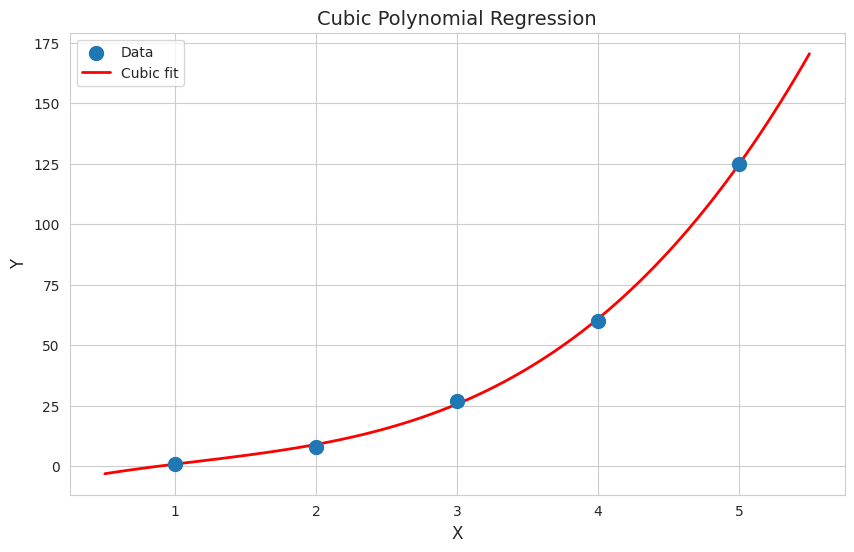

In [11]:
# 問題2の解答
print("問題2: 3次多項式回帰")
print("="*50)

X_prob = np.array([1, 2, 3, 4, 5])
Y_prob = np.array([1, 8, 27, 60, 125])

beta = polynomial_regression(X_prob, Y_prob, 3)

print(f"\n回帰式: Y = {beta[0]:.4f} + {beta[1]:.4f}*X + {beta[2]:.4f}*X² + {beta[3]:.4f}*X³")

# Verify
Y_pred = beta[0] + beta[1]*X_prob + beta[2]*X_prob**2 + beta[3]*X_prob**3
print(f"\n予測値: {np.round(Y_pred, 2)}")
print(f"実測値: {Y_prob}")

# Plot
X_plot = np.linspace(0.5, 5.5, 100)
Y_plot = beta[0] + beta[1]*X_plot + beta[2]*X_plot**2 + beta[3]*X_plot**3

plt.figure(figsize=(10, 6))
plt.scatter(X_prob, Y_prob, s=100, zorder=5, label='Data')
plt.plot(X_plot, Y_plot, 'r-', linewidth=2, label='Cubic fit')
plt.xlabel('X', fontsize=12)
plt.ylabel('Y', fontsize=12)
plt.title('Cubic Polynomial Regression', fontsize=14)
plt.legend()
plt.show()

In [12]:
# 問題3の解答
print("問題3: 多項式回帰の次数選択方法")
print("="*60)

print("""
【次数選択の方法】

1. 交差検証（Cross-validation）
   - データを訓練・検証に分割
   - 各次数でCVエラーを計算
   - 最小エラーの次数を選択

2. 情報量基準
   - AIC: -2*log(L) + 2*k
   - BIC: -2*log(L) + k*log(n)
   - 最小のAIC/BICを持つ次数を選択

3. 調整済みR²
   - R²_adj = 1 - (1-R²)*(n-1)/(n-p-1)
   - 最大のR²_adjを持つ次数を選択

4. F検定
   - 次数を1つ増やしたときの改善が有意か検定
   - 有意でなくなるまで次数を増やす

【注意点】
- 訓練誤差のみでは過学習を検出できない
- 次数が高すぎると外挿が不安定
- ドメイン知識も考慮する
""")

問題3: 多項式回帰の次数選択方法

【次数選択の方法】

1. 交差検証（Cross-validation）
   - データを訓練・検証に分割
   - 各次数でCVエラーを計算
   - 最小エラーの次数を選択

2. 情報量基準
   - AIC: -2*log(L) + 2*k
   - BIC: -2*log(L) + k*log(n)
   - 最小のAIC/BICを持つ次数を選択

3. 調整済みR²
   - R²_adj = 1 - (1-R²)*(n-1)/(n-p-1)
   - 最大のR²_adjを持つ次数を選択

4. F検定
   - 次数を1つ増やしたときの改善が有意か検定
   - 有意でなくなるまで次数を増やす

【注意点】
- 訓練誤差のみでは過学習を検出できない
- 次数が高すぎると外挿が不安定
- ドメイン知識も考慮する



## ⚠️ よくある間違いと解決策

統計分析では、手法の前提条件を確認せずに適用してしまうことがよくあります。必ず前提を確認し、適切な手法を選択しましょう。

---

## 📝 理解度チェック

この章で学んだ内容を振り返り、重要な概念を自分の言葉で説明できるか確認しましょう。

---

## 📚 まとめ

お疲れ様でした！この章で学んだ手法は、実際のデータ分析で頻繁に使われます。実データで試して理解を深めましょう。

---